![Astrofisica Computacional](../new_logo.png)

# Computational Astrophysics – `Astroquery` II

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---
Taken from previous lectures of this course.



### About this notebook

In this worksheet we will present an example of the use of `Astroquery` to get the spectrum of an object from the SDSS database. 

---

---

## Obtaining an spectrum from the SDSS

First, we import the functions we need,

In [1]:
import matplotlib 
#matplotlib.use('Agg')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline 

# Python standard-libraries to download data from the web
from urllib.parse import urlencode
from urllib.request import urlretrieve

#Some astropy submodules that you know already
from astropy import units as u
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy.io import fits

#only here to display images
from IPython.display import Image

# These are the new modules for this notebook
from astroquery.simbad import Simbad
from astroquery.sdss import SDSS

We will work with the galaxy [NGC5406](http://simbad.u-strasbg.fr/simbad/sim-id?Ident=NGC+5406)

In [2]:
galaxy_name = 'NGC5406'

# Information from the name of the galaxy in the SkyCoord server
galaxy = SkyCoord.from_name(galaxy_name)
galaxy

<SkyCoord (ICRS): (ra, dec) in deg
    (210.08384725, 38.91540956)>

In [3]:
# Get the coordinates of the galaxy
pos = coords.SkyCoord(galaxy.ra, galaxy.dec, frame='icrs')
pos

<SkyCoord (ICRS): (ra, dec) in deg
    (210.08384725, 38.91540956)>

### Image of the galaxy

We will get the image of the galaxy from the [SDSS DR12 cutout service](http://skyservice.pha.jhu.edu/sdsscutout/)

Ypu can find information about the APIs in the skyserver at [https://skyserver.sdss.org/dr18/Support/Api](https://skyserver.sdss.org/dr18/Support/Api)

In [4]:
import requests
import PIL 
#from PIL import Image

im_size = 3*u.arcmin # get a 3 arcmin square
im_pixels = 1024

# Define the URL to dowload the cutout
#cutoutbaseurl = 'http://skyservice.pha.jhu.edu/DR12/ImgCutout/getjpeg.aspx'
cutoutbaseurl ='http://skyserver.sdss.org/dr16/SkyServerWS/ImgCutout/getjpeg'
query_string = urlencode(dict(ra=galaxy.ra.deg,
                              dec=galaxy.dec.deg,
                              width=im_pixels, height=im_pixels,
                              scale=im_size.to(u.arcsec).value/im_pixels))
url = cutoutbaseurl + '?' + query_string

# Download the image
image_name = galaxy_name+'_SDSS_cutout.jpg'
#urlretrieve(url, image_name)
img = PIL.Image.open(requests.get(url, stream = True).raw)
img.save(image_name)

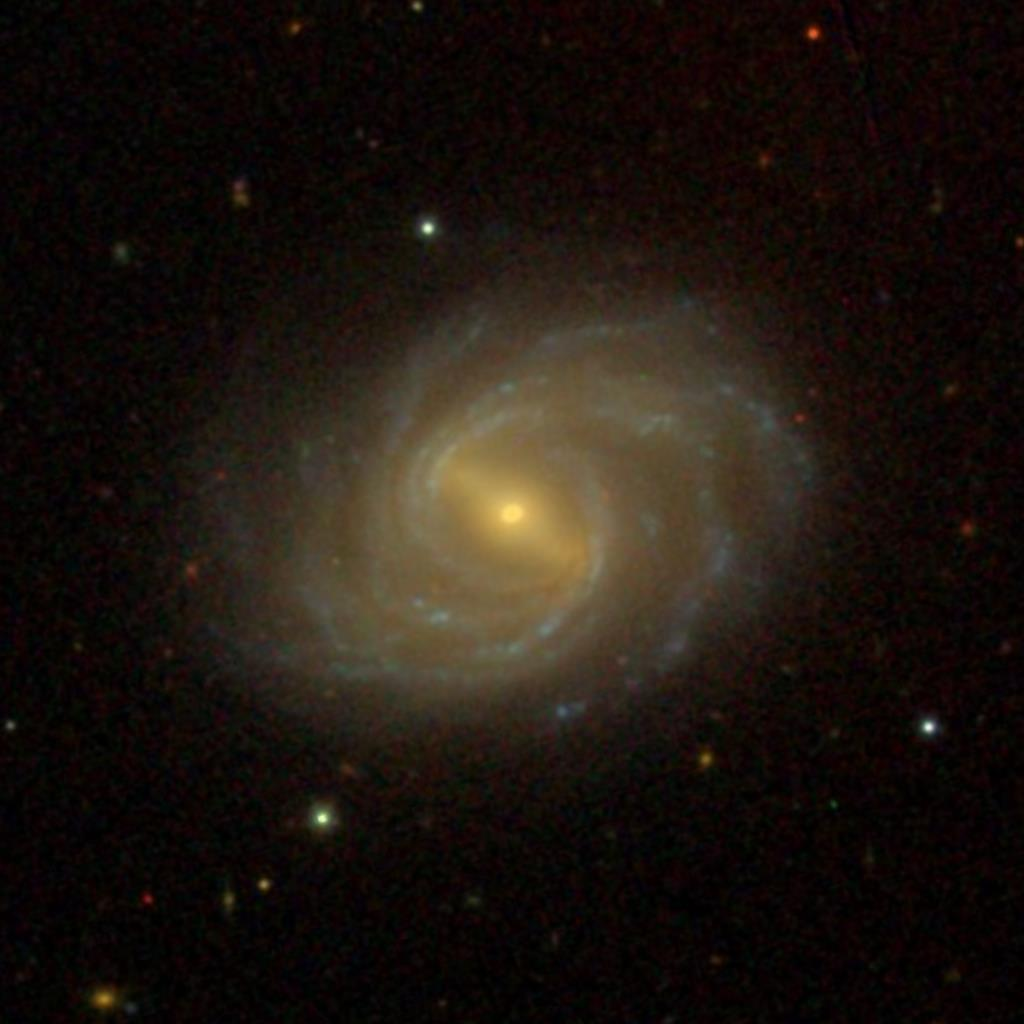

In [5]:
#load the .jpg image into the notebook
Image(image_name) 

### Data from the SDSS

Now we will get the identification numbers to grab the data from SDSS,

In [6]:
xid = SDSS.query_region(pos, spectro=True,radius=2.5*u.arcmin)
xid

ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,str7
210.083659439651,38.9087810079767,1237662305650999382,3919,301,2,56,0.01785608,10759,58526,514,12113698528007837696,v5_13_2
210.088187579391,38.9178436760813,1237662305650999367,3919,301,2,56,0.01767732,1378,53061,2,1551490672740034560,26
210.08382882614,38.9154295387748,1237662305650999364,3919,301,2,56,0.01794657,1379,53063,310,1552701235075770368,26
210.08382882614,38.9154295387748,1237662305650999364,3919,301,2,56,0.01797222,1379,53084,313,1552702060061812736,26
210.057704156783,38.9050005648143,1237662305650999366,3919,301,2,56,3.265524,1378,53061,8,1551492322007476224,26
210.057704156783,38.9050005648143,1237662305650999366,3919,301,2,56,3.271445,4711,55737,566,5304270138283153408,v5_13_2
210.062580445852,38.8774006644835,1237662305650999618,3919,301,2,56,1.405047,10759,58526,516,12113699077763651584,v5_13_2


We obtain the spectra of the object from the SDSS

In [7]:
spectra = SDSS.get_spectra(matches=xid)
# List of results
spectra

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x769106d33550>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075788050>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690757c3810>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690757ce090>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690755e7350>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690755fc690>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075615850>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x76907562aa10>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075643bd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075658dd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075671f90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075687150>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7690757063d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x76907568c8d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690758ae890>, <astrop

`spectra[0]` stores all the files related to the spectra for the object of interest. This is actually an array of several HDU in the FITS format

In [8]:
spectra[0]

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x769106d33550>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075788050>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690757c3810>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690757ce090>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690755e7350>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690755fc690>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075615850>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x76907562aa10>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075643bd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075658dd0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075671f90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x769075687150>]

The spectrum is stored as a table in the component [0][1] of this object. That means that we can get the Table doing the following

In [9]:
spectra_data = spectra[0][1].data
spectra_data

FITS_rec([( 8.9795685 , 3.5551, 0.05065062, 0, 16777216, 0.9437546 ,  6.8026037, 5.898777 ),
          (-3.5353034 , 3.5552, 0.04698995, 0, 17367040, 0.94454885,  6.7716126, 5.9691124),
          ( 8.889782  , 3.5553, 0.07342292, 0, 589824, 1.0139439 ,  7.5034623, 6.0953608),
          ...,
          ( 0.38676178, 4.0149, 0.06194206, 0, 8388608, 0.7572991 , 66.58914  , 3.0812597),
          ( 6.651608  , 4.015 , 0.03932417, 0, 8388608, 0.75671494, 88.222244 , 3.081034 ),
          (11.602152  , 4.0151, 0.06064145, 0, 0, 0.75714314, 34.530922 , 3.0808053)],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4')]))

Note the structure of that table. Pay attention to the field dtype (data type). It tells you the name of the different columns available in that table.

Please also check the documentation so that you can see what are the units https://data.sdss.org/datamodel/files/BOSS_SPECTRO_REDUX/RUN2D/spectra/PLATE4/spec.html

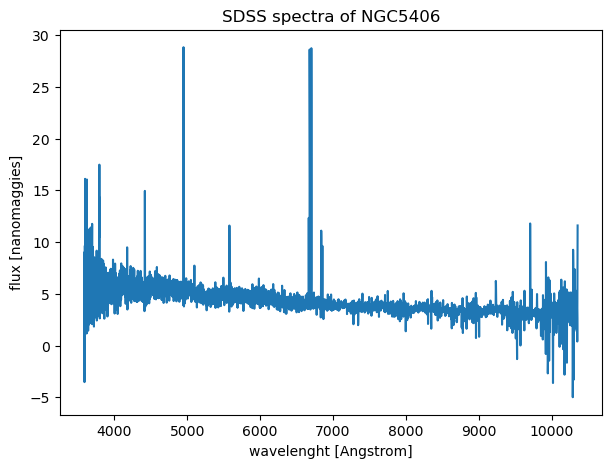

In [10]:
plt.figure(figsize=(7,5))
plt.plot(10**spectra_data['loglam'], spectra_data['flux'])
plt.xlabel('wavelenght [Angstrom]')
plt.ylabel('flux [nanomaggies]')
plt.title('SDSS spectra of '+galaxy_name)
plt.show()

The component [0][3] of the object 'spectra' contains the positions of some emission lines

In [11]:
lines = spectra[0][3].data
lines

FITS_rec([(10759, 58526, 514, 'Ly_alpha', 1215.67      , 0.        , -1.0000000e+00,  0.     , -1.       ,  0.00000000e+00, -1.       ,  0.00000000e+00, -1.        , 0.       , -1.        , 0, 0, 0.       , -1.       ),
          (10759, 58526, 514, 'N_V 1240', 1240.81      , 0.        , -1.0000000e+00,  0.     , -1.       ,  0.00000000e+00, -1.       ,  0.00000000e+00, -1.        , 0.       , -1.        , 0, 0, 0.       , -1.       ),
          (10759, 58526, 514, 'C_IV 1549', 1549.48      , 0.        , -1.0000000e+00,  0.     , -1.       ,  0.00000000e+00, -1.       ,  0.00000000e+00, -1.        , 0.       , -1.        , 0, 0, 0.       , -1.       ),
          (10759, 58526, 514, 'He_II 1640', 1640.42      , 0.        , -1.0000000e+00,  0.     , -1.       ,  0.00000000e+00, -1.       ,  0.00000000e+00, -1.        , 0.       , -1.        , 0, 0, 0.       , -1.       ),
          (10759, 58526, 514, 'C_III] 1908', 1908.734     , 0.        , -1.0000000e+00,  0.     , -1.       ,  0.0000

The lines in this spectrum are

In [12]:
lines['LINENAME']

chararray(['Ly_alpha', 'N_V 1240', 'C_IV 1549', 'He_II 1640',
           'C_III] 1908', 'Mg_II 2799', '[O_II] 3725', '[O_II] 3727',
           '[Ne_III] 3868', 'H_zeta', '[Ne_III] 3970', 'H_epsilon',
           'H_delta', 'H_gamma', '[O_III] 4363', 'He_II 4685', 'H_beta',
           '[O_III] 4959', '[O_III] 5007', 'He_II 5411', '[O_I] 5577',
           '[N_II] 5755', 'He_I 5876', '[O_I] 6300', '[S_III] 6312',
           '[O_I] 6363', '[N_II] 6548', 'H_alpha', '[N_II] 6583',
           '[S_II] 6716', '[S_II] 6730', '[Ar_III] 7135'], dtype='<U13')

We will plot three of these lines: '[O_II] 3727', '[O_III] 5007' and 'H_alpha'. The corresponding wavelengths are

In [13]:
for n in ['[O_II] 3727', '[O_III] 5007', 'H_alpha']:
    print(n, " ->", lines['LINEWAVE'][lines['LINENAME']==n])

[O_II] 3727  -> [3729.87544376]
[O_III] 5007  -> [5008.23966962]
H_alpha  -> [6564.61397371]


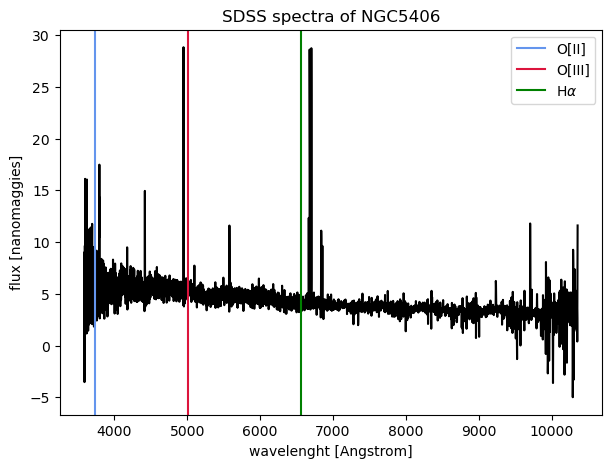

In [14]:
plt.figure(figsize=(7,5))
plt.plot(10**spectra_data['loglam'], spectra_data['flux'], color='black')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='[O_II] 3727'], label=r'O[II]', color='cornflowerblue')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='[O_III] 5007'], label=r'O[III]', color='crimson')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='H_alpha'], label=r'H$\alpha$', color='green')

plt.xlabel('wavelenght [Angstrom]')
plt.ylabel('flux [nanomaggies]')
plt.title('SDSS spectra of '+galaxy_name)
plt.legend()
plt.show()

### Photometric image

Now we will obtain the photometric information of the galaxy.  We can get the images in the different SDSS bands (u,g,r,i,z)

The documentation describing the imaging data is here: https://data.sdss.org/datamodel/files/BOSS_PHOTOOBJ/frames/RERUN/RUN/CAMCOL/frame.html

In [15]:
# Get the photometric inoformation in the g-band
images = SDSS.get_images(matches=xid, band='g')
images

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7690736bd2d0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x7690734ae710>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690734b0090>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690734b3d10>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7690734663d0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x7690734bc4d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690734bd950>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690732cd6d0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x769073481450>, <astropy.io.fits.hdu.image.ImageHDU object at 0x7690732cdf10>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690732cf350>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690732d70d0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x769073448810>, <astropy.io.fits.hdu.image.ImageHDU object at 0x7690732d7990>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7690732e0e50>, <astropy.io.fit

The component [0][0] of the object 'images' contains the photometric information,

In [16]:
image_data =  images[0][0].data

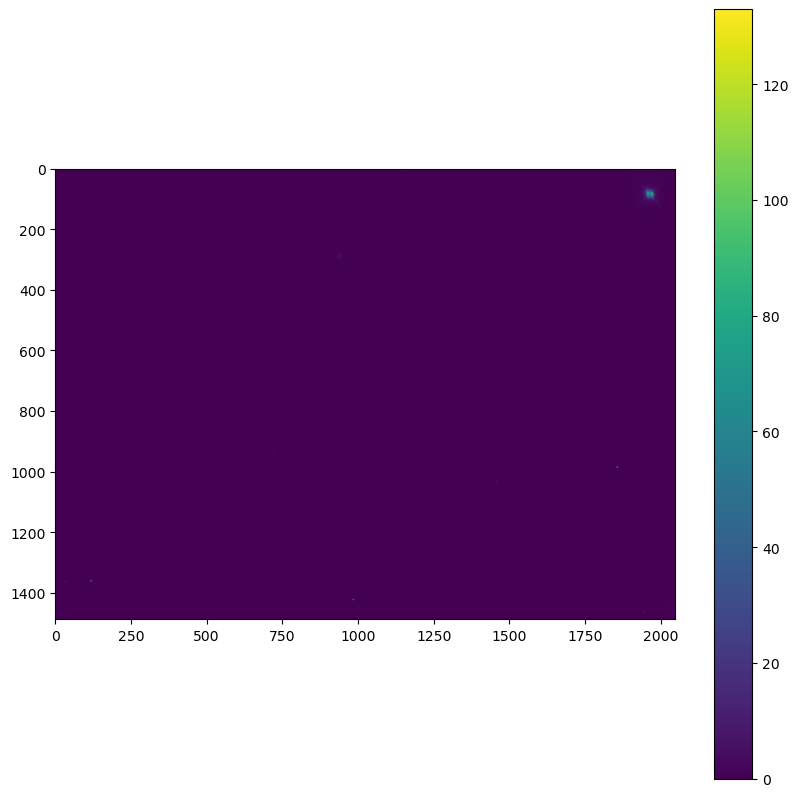

In [17]:
plt.figure(figsize=(10,10))
plt.imshow(image_data)
plt.colorbar()
plt.show()

The galaxy is not shown because the flux values in some of the pixels are very high compared to the typical flux.

To see the image, we will create a 'clipped image'. This will make that any pixel with a flux larger than 1 will be set 'normalized' to 1.

In [18]:
clipped_image = image_data.copy()
clipped_image[clipped_image>1.0]=1.0

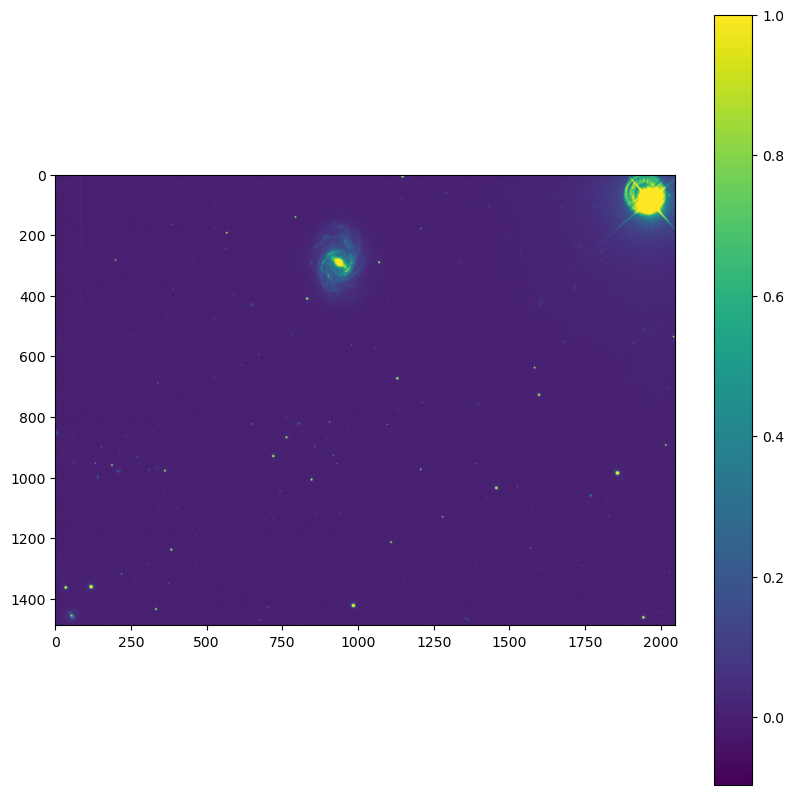

In [19]:
plt.figure(figsize=(10,10))
plt.imshow(clipped_image)
plt.colorbar()
plt.show()

Now the galaxy is shown. Now we will crop the image to the region where the galaxy is located,

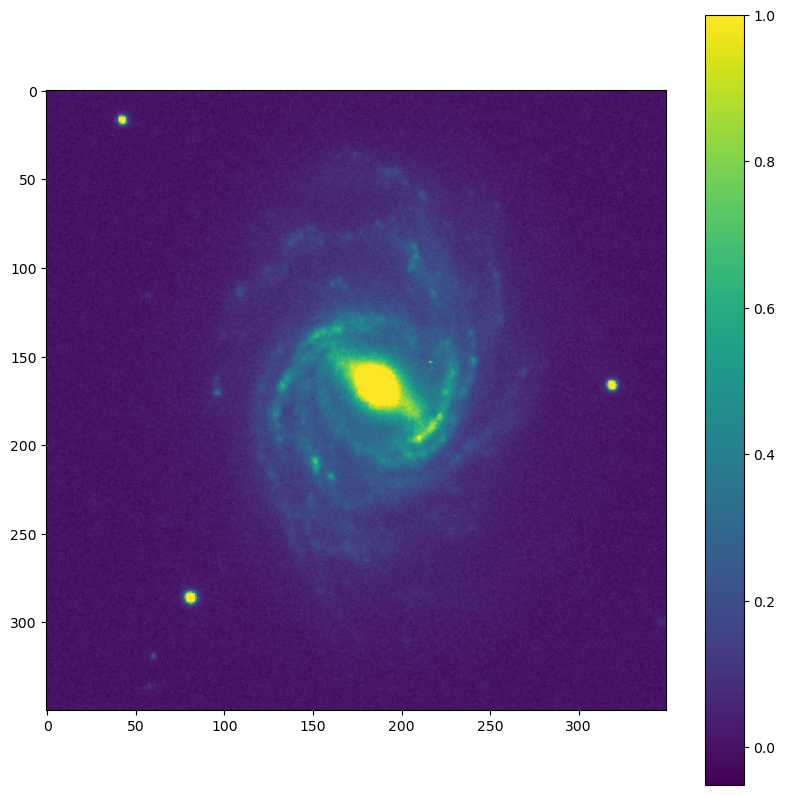

In [20]:
plt.figure(figsize=(10,10))
plt.imshow(clipped_image[125:475,750:1100])
plt.colorbar()
plt.show()

A similar result can be obtained from the original data by taking the logarithm of the flux.

/tmp/ipykernel_362568/535572027.py:2: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(image_data[125:475,750:1100]))


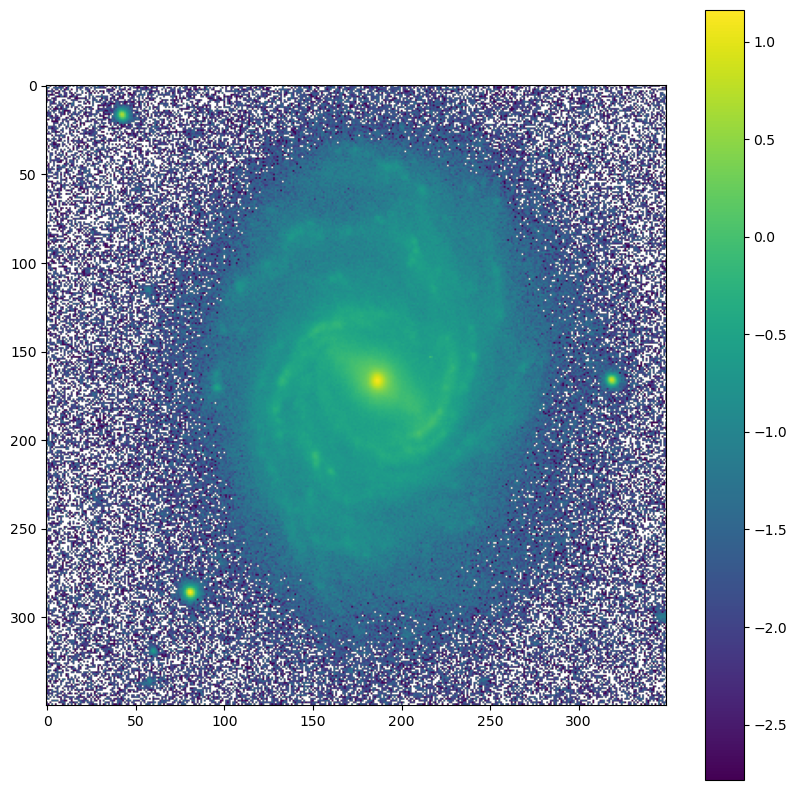

In [21]:
plt.figure(figsize=(10,10))
plt.imshow(np.log10(image_data[125:475,750:1100]))
plt.colorbar()
plt.show()

The missing points appear due to negative values in the image data. We can modify the image by using the minimum value,

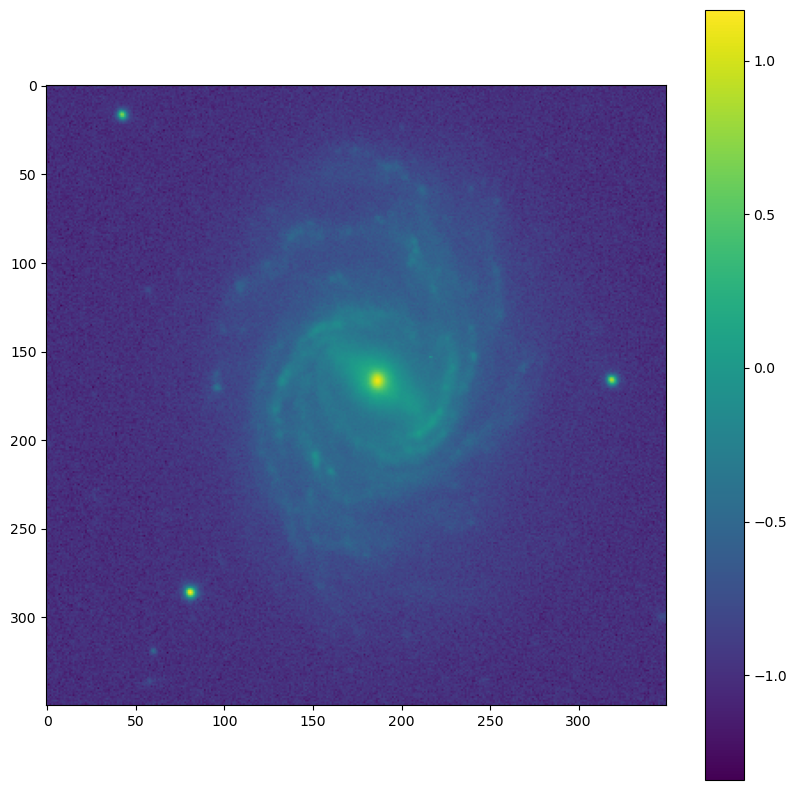

In [22]:
image_data2 = image_data - np.min(image_data)
plt.figure(figsize=(10,10))
plt.imshow(np.log10(image_data2[125:475,750:1100]))
plt.colorbar()
plt.show()

#### Exercise 1

Identify at least three of the lines seen in the spectrum of NGC5406. Using that information, what is the redshift of this galaxy?

#### Exercise 2

Download the FITS images in the filters u,g,r,z,i for NGC5406. Plot in five different panels the logarithm of the flux in each of the bands (always cropping around the galaxy). Why do the images look different?

#### Exercise 3

Compute the radial flux profile of NGC5406. To do that take 10 different lines starting from the center of the galaxy and plot the flux as a function of radius for those ten lines. What kind of function should fit your results?

#### Exercise 4

Repeat the same producedure of this notebook (including the exercises 2 and 3) for the galaxy `SDSS J013755.71+010004.9`.

Why does this galaxy look so different from NGC5406?
